# Conditional GAN

*не обязательно использовать данный код, можно создать свою собственную модель GAN и модифицировать её 

уже писал GAN для MNIST, поэтому модифицировал свой код на tensorflow, раз такая возможность имеется

P. S. учил на колабе

In [16]:
import os
import time
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from IPython import display
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
(train_images, train_labels), (_, _) = tf.keras.datasets.mnist.load_data()
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')
train_images = (train_images - 127.5) / 127.5  

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Параметры
BUFFER_SIZE = 60000
BATCH_SIZE = 256
EPOCHS = 150
noise_dim = 100
num_classes = 10

In [ ]:
# Собираем батчи в нужном формате
train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
train_dataset = train_dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)

In [ ]:
# Генератор
def make_generator_model():
    model = tf.keras.Sequential()

    # Вход noise_dim + num_classes
    model.add(layers.Dense(7 * 7 * 256, use_bias=False, input_shape=(100 + 10,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))

    return model

In [ ]:
# Дискриминатор
def make_discriminator_model():
    model = tf.keras.Sequential()

    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same',
                           input_shape=[28, 28, 1 + num_classes]))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

In [ ]:
generator = make_generator_model()
discriminator = make_discriminator_model()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Функции потерь и оптимизаторы
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

In [10]:
generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

In [11]:
# Функция для добавления меток к изображениям
def add_label_channel(images, labels):
    labels_one_hot = tf.one_hot(labels, depth=num_classes)
    labels_one_hot = tf.reshape(labels_one_hot, [-1, 1, 1, num_classes])
    labels_one_hot = tf.tile(labels_one_hot, [1, 28, 28, 1])
    return tf.concat([images, labels_one_hot], axis=-1)

In [ ]:
@tf.function
def train_step(images, labels):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # Добавление к шуму меток
        noise_with_labels = tf.concat([noise, tf.one_hot(labels, depth=num_classes)], axis=1)
        generated_images = generator(noise_with_labels, training=True)

        real_output = discriminator(add_label_channel(images, labels), training=True)
        fake_output = discriminator(add_label_channel(generated_images, labels), training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

In [ ]:
# Функция для анимашки
def generate_and_save_images(model, epoch, test_input, test_labels):
    noise_with_labels = tf.concat([test_input, tf.one_hot(test_labels, depth=num_classes)], axis=1)
    predictions = model(noise_with_labels, training=False)

    plt.figure(figsize=(10, 10))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.title(f"Label: {test_labels[i]}")
        plt.axis('off')

    plt.savefig(f'/content/drive/MyDrive/gan/images/image_at_epoch_{epoch:04d}.png')
    plt.show()

In [ ]:
def train(dataset, epochs):
    # Для анимашки использовал фиксированный шум
    num_examples_to_generate = 16
    seed = tf.random.normal([num_examples_to_generate, noise_dim])
    example_labels = tf.constant([i % num_classes for i in range(num_examples_to_generate)], dtype=tf.int32)

    for epoch in range(epochs):
        start = time.time()

        for image_batch, label_batch in dataset:
            if image_batch.shape[0] == BATCH_SIZE:
                train_step(image_batch, label_batch)

        display.clear_output(wait=True)
        generate_and_save_images(generator, epoch + 1, seed, example_labels)

        print(f'Epoch {epoch + 1}, Time: {time.time() - start:.2f} sec')

    display.clear_output(wait=True)
    generate_and_save_images(generator, epochs, seed, example_labels)

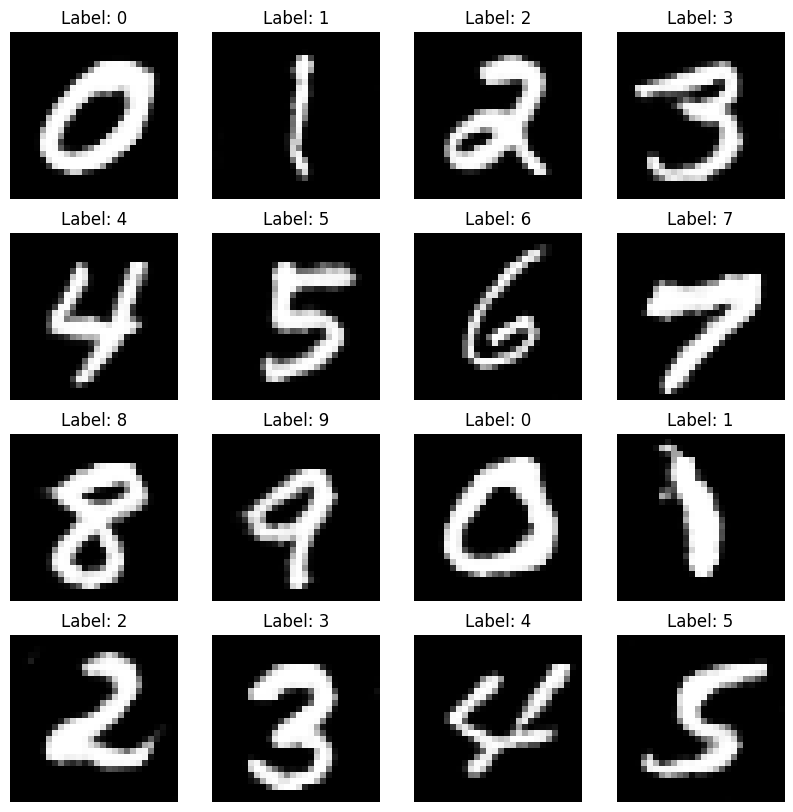

In [ ]:
train(train_dataset, EPOCHS)

In [ ]:
generator.save('/content/drive/MyDrive/gan/cgan_generator.keras')
discriminator.save('/content/drive/MyDrive/gan/cgan_discriminator.keras')

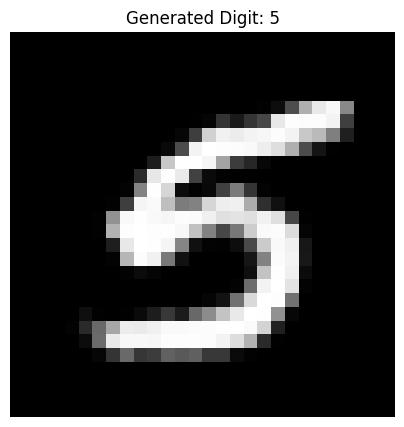

In [ ]:
def generate_digit(digit, num_examples=1):
    noise = tf.random.normal([num_examples, noise_dim])
    labels = tf.constant([digit] * num_examples, dtype=tf.int32)
    noise_with_labels = tf.concat([noise, tf.one_hot(labels, depth=num_classes)], axis=1)
    generated_images = generator(noise_with_labels, training=False)

    plt.figure(figsize=(5, 5))
    plt.imshow(generated_images[0, :, :, 0] * 127.5 + 127.5, cmap='gray')
    plt.axis('off')
    plt.title(f"Generated Digit: {digit}")
    plt.show()


generate_digit(5)